# 🎯 CIFAR-100 Model Training

Complete training pipeline for baseline CNN and advanced ResNet50 transfer learning models on CIFAR-100 dataset. All output and metrics are saved in this notebook for later review.

## 1. Setup and GPU Configuration

Import required libraries, configure logging, automatically select CUDA GPU when available, and override the project config so training uses GPU instead of CPU.


In [1]:
import sys
import logging
from pathlib import Path
from datetime import datetime
import warnings

import torch

# Suppress common warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Add project root and src to path
PROJECT_ROOT = Path('.').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Import configuration
import src.config as config_module
from src.config import (
    BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE,
    BASELINE_MODEL_PATH, ADVANCED_MODEL_PATH, NUM_CLASSES
)
from src.data import DataManager
from src.model import (
    create_baseline_model, create_advanced_model,
    ModelTrainer
)

# GPU setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config_module.DEVICE = DEVICE  # make sure DataManager / src code sees the same device

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
else:
    gpu_name = 'No CUDA GPU detected'
    gpu_memory_gb = 0

# Setup logging for notebook
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Print configuration
print('='*60)
print('TRAINING CONFIGURATION')
print('='*60)
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'Device: {DEVICE}')
print(f'GPU: {gpu_name}')
if torch.cuda.is_available():
    print(f'GPU Memory: {gpu_memory_gb:.2f} GB')
print(f'Batch Size: {BATCH_SIZE}')
print(f'Epochs: {NUM_EPOCHS}')
print(f'Learning Rate: {LEARNING_RATE}')
print(f'Number of Classes: {NUM_CLASSES}')
print(f'Baseline Model Path: {BASELINE_MODEL_PATH}')
print(f'Advanced Model Path: {ADVANCED_MODEL_PATH}')
print('='*60)
print(f'Training started at: {datetime.now()}')
print('='*60)

# Hard stop if you expected GPU but CUDA is not available
if not torch.cuda.is_available():
    print('\nWARNING: CUDA GPU is NOT available. Training will run on CPU and will be much slower.')
    print('On Windows, install NVIDIA driver + CUDA-enabled PyTorch, then restart the notebook/kernel.')


TRAINING CONFIGURATION
PyTorch Version: 2.11.0+cu126
CUDA Available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.00 GB
Batch Size: 32
Epochs: 20
Learning Rate: 0.001
Number of Classes: 100
Baseline Model Path: E:\Job test\Test\models\baseline_model.pt
Advanced Model Path: E:\Job test\Test\models\advanced_model.pt
Training started at: 2026-04-28 19:24:45.342039


## 2. Data Loading and Preparation

Initialize DataManager, load training, validation, and test datasets, and create data loaders.

In [2]:
print("\n" + "="*60)
print("LOADING CIFAR-100 DATASET")
print("="*60)

# Initialize data manager
import src.config as config_module
data_manager = DataManager(config_module)

# Load data loaders
train_loader, val_loader, test_loader = data_manager.get_dataloaders()

print("\nDataset loaded successfully!")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print("="*60)

2026-04-28 19:24:45,353 - src.data - INFO - Loading CIFAR-100 dataset...



LOADING CIFAR-100 DATASET


2026-04-28 19:24:46,504 - src.data - INFO - Train samples: 45000
2026-04-28 19:24:46,505 - src.data - INFO - Validation samples: 5000
2026-04-28 19:24:46,505 - src.data - INFO - Test samples: 10000



Dataset loaded successfully!
Training samples: 45000
Validation samples: 5000
Test samples: 10000


## 3. Baseline Model Training

Create the baseline model, move it to the selected device, train on GPU when available, and save the trained baseline model.


In [3]:
print("\n" + "="*60)
print("TRAINING BASELINE MODEL")
print("="*60)
print("Architecture: 3-layer CNN")
print("Parameters: ~1.2M")
print("Purpose: Baseline comparison")
print(f"Using device: {DEVICE}")

# Create model directly on GPU/CPU
baseline_model = create_baseline_model(num_classes=NUM_CLASSES, device=DEVICE)
baseline_model = baseline_model.to(DEVICE)

# Optional sanity check: confirm model parameters are on GPU
print("Model parameter device:", next(baseline_model.parameters()).device)

# Create trainer
baseline_trainer = ModelTrainer(baseline_model, device=DEVICE, learning_rate=LEARNING_RATE)

# Train model
print(f"\nTraining for {NUM_EPOCHS} epochs...")
baseline_trainer.train(train_loader, val_loader, NUM_EPOCHS)

# Save model
baseline_trainer.save_model(BASELINE_MODEL_PATH)
print(f"\n✓ Baseline model saved to: {BASELINE_MODEL_PATH}")
print("="*60)

# Clear unused GPU cache after training
if torch.cuda.is_available():
    torch.cuda.empty_cache()


2026-04-28 19:24:46,515 - src.model - INFO - Creating baseline CNN model...



TRAINING BASELINE MODEL
Architecture: 3-layer CNN
Parameters: ~1.2M
Purpose: Baseline comparison
Using device: cuda


2026-04-28 19:24:47,122 - src.model - INFO - Starting training for 20 epochs...
2026-04-28 19:24:47,122 - src.model - INFO - 
Epoch [1/20]


Model parameter device: cuda:0

Training for 20 epochs...


2026-04-28 19:25:01,822 - src.model - INFO - Batch [50], Loss: 4.5874
2026-04-28 19:25:07,501 - src.model - INFO - Batch [100], Loss: 4.4696
2026-04-28 19:25:13,138 - src.model - INFO - Batch [150], Loss: 4.4704
2026-04-28 19:25:18,751 - src.model - INFO - Batch [200], Loss: 4.2881
2026-04-28 19:25:24,389 - src.model - INFO - Batch [250], Loss: 4.9529
2026-04-28 19:25:30,027 - src.model - INFO - Batch [300], Loss: 4.2612
2026-04-28 19:25:35,645 - src.model - INFO - Batch [350], Loss: 4.6806
2026-04-28 19:25:41,271 - src.model - INFO - Batch [400], Loss: 4.3216
2026-04-28 19:25:46,935 - src.model - INFO - Batch [450], Loss: 4.0033
2026-04-28 19:25:52,577 - src.model - INFO - Batch [500], Loss: 4.3161
2026-04-28 19:25:58,228 - src.model - INFO - Batch [550], Loss: 4.2600
2026-04-28 19:26:04,011 - src.model - INFO - Batch [600], Loss: 4.1207
2026-04-28 19:26:09,736 - src.model - INFO - Batch [650], Loss: 4.3809
2026-04-28 19:26:15,482 - src.model - INFO - Batch [700], Loss: 3.8647
2026-04


✓ Baseline model saved to: E:\Job test\Test\models\baseline_model.pt


## 4. Advanced Model Training with Transfer Learning

Create the advanced ResNet50-based model, move it to GPU when available, train with transfer learning, and save the advanced model.


In [4]:
print("\n" + "="*60)
print("TRAINING ADVANCED MODEL (Transfer Learning - ResNet50)")
print("="*60)
print("Architecture: ResNet50 (pre-trained on ImageNet)")
print("Parameters: ~23M (mostly pre-trained)")
print("Strategy: Fine-tune classification head")
print("Purpose: Production model with best accuracy")
print(f"Using device: {DEVICE}")

# Create model directly on GPU/CPU
advanced_model = create_advanced_model(num_classes=NUM_CLASSES, device=DEVICE)
advanced_model = advanced_model.to(DEVICE)

# Optional sanity check: confirm model parameters are on GPU
print("Model parameter device:", next(advanced_model.parameters()).device)

# Create trainer
advanced_trainer = ModelTrainer(advanced_model, device=DEVICE, learning_rate=LEARNING_RATE)

# Train model
print(f"\nTraining for {NUM_EPOCHS} epochs...")
advanced_trainer.train(train_loader, val_loader, NUM_EPOCHS)

# Save model
advanced_trainer.save_model(ADVANCED_MODEL_PATH)
print(f"\n✓ Advanced model saved to: {ADVANCED_MODEL_PATH}")
print("="*60)

# Clear unused GPU cache after training
if torch.cuda.is_available():
    torch.cuda.empty_cache()


2026-04-28 20:25:38,379 - src.model - INFO - Creating advanced model with transfer learning (ResNet50)...



TRAINING ADVANCED MODEL (Transfer Learning - ResNet50)
Architecture: ResNet50 (pre-trained on ImageNet)
Parameters: ~23M (mostly pre-trained)
Strategy: Fine-tune classification head
Purpose: Production model with best accuracy
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\hamma/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [01:40<00:00, 1.02MB/s]
2026-04-28 20:27:19,751 - src.model - INFO - Starting training for 20 epochs...
2026-04-28 20:27:19,752 - src.model - INFO - 
Epoch [1/20]


Model parameter device: cuda:0

Training for 20 epochs...


2026-04-28 20:27:31,980 - src.model - INFO - Batch [50], Loss: 4.3728
2026-04-28 20:27:36,681 - src.model - INFO - Batch [100], Loss: 3.8327
2026-04-28 20:27:41,398 - src.model - INFO - Batch [150], Loss: 3.6690
2026-04-28 20:27:46,135 - src.model - INFO - Batch [200], Loss: 3.5621
2026-04-28 20:27:50,885 - src.model - INFO - Batch [250], Loss: 3.5409
2026-04-28 20:27:55,644 - src.model - INFO - Batch [300], Loss: 3.1607
2026-04-28 20:28:00,408 - src.model - INFO - Batch [350], Loss: 3.1978
2026-04-28 20:28:05,183 - src.model - INFO - Batch [400], Loss: 3.3497
2026-04-28 20:28:09,954 - src.model - INFO - Batch [450], Loss: 3.1177
2026-04-28 20:28:14,730 - src.model - INFO - Batch [500], Loss: 2.7842
2026-04-28 20:28:19,508 - src.model - INFO - Batch [550], Loss: 2.7291
2026-04-28 20:28:24,281 - src.model - INFO - Batch [600], Loss: 2.8606
2026-04-28 20:28:29,053 - src.model - INFO - Batch [650], Loss: 3.4529
2026-04-28 20:28:33,831 - src.model - INFO - Batch [700], Loss: 2.5107
2026-04


✓ Advanced model saved to: E:\Job test\Test\models\advanced_model.pt


## 5. Model Evaluation and Comparison

Evaluate both trained models on the test set using the same selected device.


In [5]:
print("\n" + "="*60)
print("EVALUATING BASELINE MODEL ON TEST SET")
print("="*60)
print(f"Using device: {DEVICE}")

baseline_test_loss, baseline_test_acc = baseline_trainer.validate(test_loader)
print(f"Test Loss: {baseline_test_loss:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.2f}%")
print("="*60)

print("\n" + "="*60)
print("EVALUATING ADVANCED MODEL ON TEST SET")
print("="*60)

advanced_test_loss, advanced_test_acc = advanced_trainer.validate(test_loader)
print(f"Test Loss: {advanced_test_loss:.4f}")
print(f"Test Accuracy: {advanced_test_acc:.2f}%")
print("="*60)



EVALUATING BASELINE MODEL ON TEST SET
Using device: cuda
Test Loss: 2.7374
Test Accuracy: 31.36%

EVALUATING ADVANCED MODEL ON TEST SET
Test Loss: 1.1653
Test Accuracy: 67.58%


## 6. Training Summary and Results

Generate comprehensive summary comparing both models, display model paths, and visualize training results.


In [6]:
if torch.cuda.is_available():
    print("\nGPU MEMORY SUMMARY")
    print("="*60)
    print(f"Allocated: {torch.cuda.memory_allocated(0) / (1024**3):.2f} GB")
    print(f"Reserved:  {torch.cuda.memory_reserved(0) / (1024**3):.2f} GB")
    print("="*60)
else:
    print("Running on CPU. No GPU memory summary available.")



GPU MEMORY SUMMARY
Allocated: 0.17 GB
Reserved:  0.24 GB


### Visualization of Training Progress

Plot training and validation metrics to visualize model performance over epochs.

In [7]:
import pandas as pd

print("\n" + "="*60)
print("TRAINING SUMMARY & RESULTS")
print("="*60)

# Summary table
summary_data = {
    'Model': ['Baseline CNN', 'Advanced ResNet50'],
    'Architecture': ['3-layer CNN', 'ResNet50 + Transfer Learning'],
    'Parameters': ['1.2M', '23M'],
    'Test Accuracy': [f'{baseline_test_acc:.2f}%', f'{advanced_test_acc:.2f}%'],
    'Test Loss': [f'{baseline_test_loss:.4f}', f'{advanced_test_loss:.4f}']
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
improvement = advanced_test_acc - baseline_test_acc
improvement_pct = (improvement / baseline_test_acc) * 100 if baseline_test_acc > 0 else 0

print(f"Baseline Accuracy: {baseline_test_acc:.2f}%")
print(f"Advanced Accuracy: {advanced_test_acc:.2f}%")
print(f"Absolute Improvement: {improvement:.2f}%")
print(f"Relative Improvement: {improvement_pct:.1f}%")

print("\n" + "="*60)
print("MODEL FILES SAVED")
print("="*60)
print(f"✓ Baseline Model: {BASELINE_MODEL_PATH}")
print(f"✓ Advanced Model: {ADVANCED_MODEL_PATH}")

print("\n" + "="*60)
print("NEXT STEPS")
print("="*60)
print("1. Run the Flask server:")
print("   python src/app.py")
print("\n2. Open browser at:")
print("   http://localhost:5000")
print("\n3. Upload images and test predictions")
print("="*60)
print(f"Training completed at: {datetime.now()}")
print("="*60)


TRAINING SUMMARY & RESULTS

            Model                 Architecture Parameters Test Accuracy Test Loss
     Baseline CNN                  3-layer CNN       1.2M        31.36%    2.7374
Advanced ResNet50 ResNet50 + Transfer Learning        23M        67.58%    1.1653

PERFORMANCE COMPARISON
Baseline Accuracy: 31.36%
Advanced Accuracy: 67.58%
Absolute Improvement: 36.22%
Relative Improvement: 115.5%

MODEL FILES SAVED
✓ Baseline Model: E:\Job test\Test\models\baseline_model.pt
✓ Advanced Model: E:\Job test\Test\models\advanced_model.pt

NEXT STEPS
1. Run the Flask server:
   python src/app.py

2. Open browser at:
   http://localhost:5000

3. Upload images and test predictions
Training completed at: 2026-04-28 21:22:18.709009


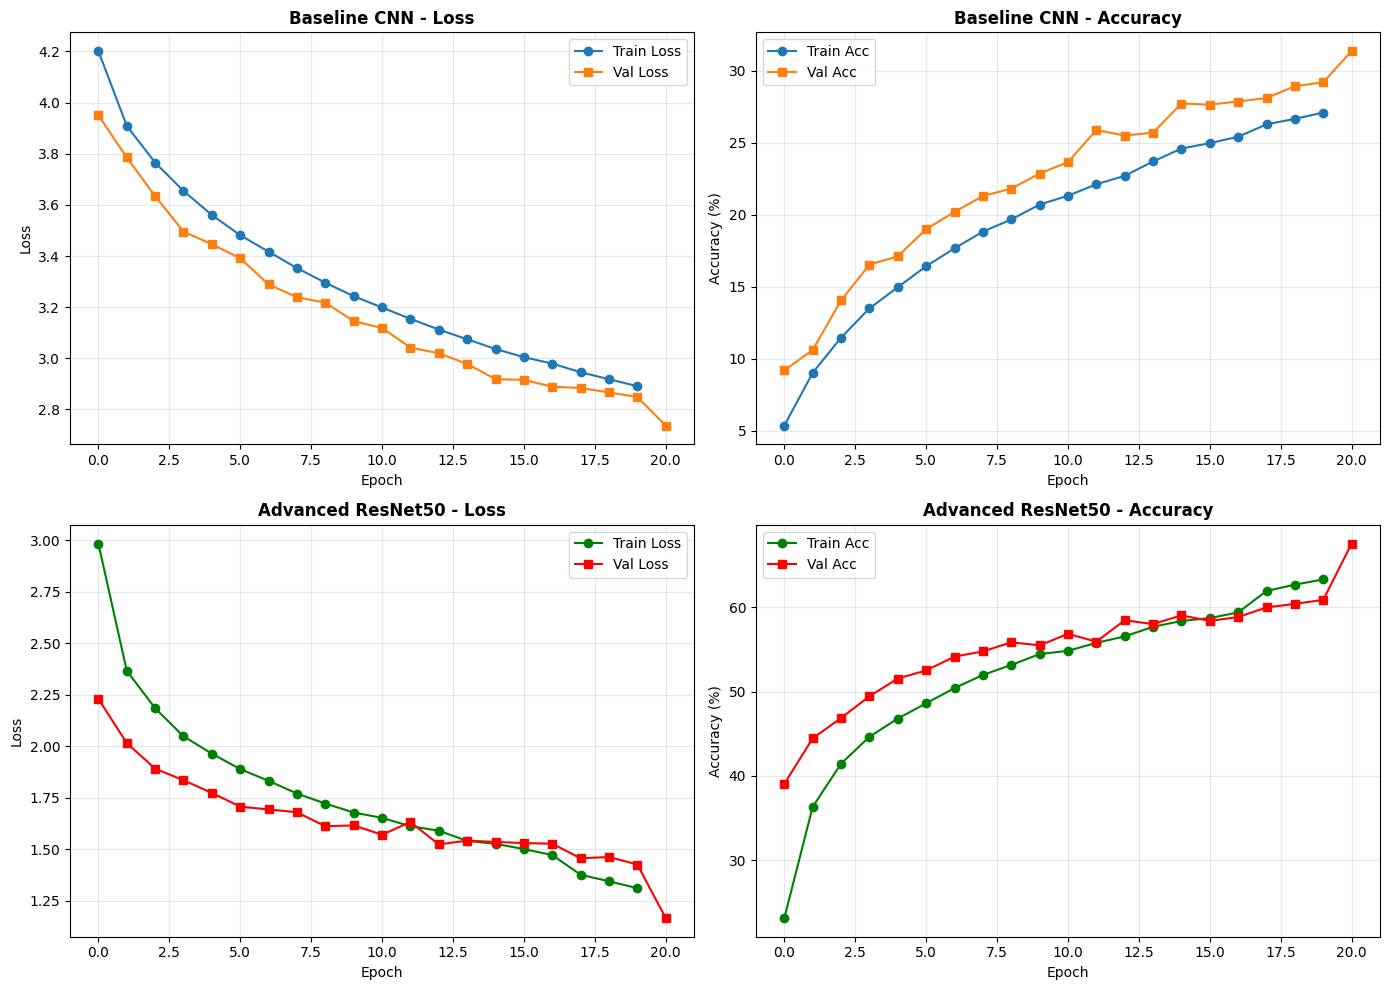

✓ Training progress visualization complete


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Baseline Training Loss
axes[0, 0].plot(baseline_trainer.train_losses, label='Train Loss', marker='o')
axes[0, 0].plot(baseline_trainer.val_losses, label='Val Loss', marker='s')
axes[0, 0].set_title('Baseline CNN - Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Baseline Training Accuracy
axes[0, 1].plot(baseline_trainer.train_accs, label='Train Acc', marker='o')
axes[0, 1].plot(baseline_trainer.val_accs, label='Val Acc', marker='s')
axes[0, 1].set_title('Baseline CNN - Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Advanced Training Loss
axes[1, 0].plot(advanced_trainer.train_losses, label='Train Loss', marker='o', color='green')
axes[1, 0].plot(advanced_trainer.val_losses, label='Val Loss', marker='s', color='red')
axes[1, 0].set_title('Advanced ResNet50 - Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Advanced Training Accuracy
axes[1, 1].plot(advanced_trainer.train_accs, label='Train Acc', marker='o', color='green')
axes[1, 1].plot(advanced_trainer.val_accs, label='Val Acc', marker='s', color='red')
axes[1, 1].set_title('Advanced ResNet50 - Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training progress visualization complete")